In [1]:
# =========================
# CELDA 1 — Imports + rutas + config
# =========================
import numpy as np
import nibabel as nib
from pathlib import Path
from collections import defaultdict, Counter
import random
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, IntSlider
import cv2

from scipy.ndimage import affine_transform  # transform geométrico 2D

# -------------------------
# RUTAS
# -------------------------
IN_DIR = Path("/users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices")
assert IN_DIR.exists(), f"No existe: {IN_DIR}"
print("IN_DIR:", IN_DIR)

OUT_AUG_ROOT = IN_DIR / "32slices_dataaugmentation"
OUT_AUG_ROOT.mkdir(parents=True, exist_ok=True)
print("OUT_AUG_ROOT:", OUT_AUG_ROOT)

(ALL_DIR := OUT_AUG_ROOT / "all").mkdir(parents=True, exist_ok=True)
print("ALL_DIR:", ALL_DIR)

# -------------------------
# CONFIG
# -------------------------
WIN = 32
EXPECTED_HW = (512, 512)
SEED = 42

# -------------------------
# AUG CONFIG
# -------------------------
DO_FLIP_ALWAYS = True

# Rot90 discreta (k=1/2/3) con probabilidad (0.0 = desactivar)
P_ROT90 = 0.25

# Affine suave (rot pequeña + shift + zoom) con probabilidad (0.0 = desactivar)
P_AFFINE = 0.40

# Máximo de augmentations EXTRA por volumen (además de orig y flip)
N_EXTRA_AUG_PER_VOL = 2

# Parámetros affine (más grandes)
AFF_ROT_DEG = 15          # rotación: +-15 grados
SHIFT_PX = 15             # traslación: +-15 px
ZOOM_RANGE = (0.90, 1.10) # zoom: +-0.10

# Padding (para zonas fuera de imagen tras transform)
CT_PAD_VALUE = 0.0
MS_PAD_VALUE = 0

random.seed(SEED)
np.random.seed(SEED)

IN_DIR: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices
OUT_AUG_ROOT: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/32slices_dataaugmentation
ALL_DIR: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/32slices_dataaugmentation/all


In [5]:
# =========================
# CELDA 2 (FINAL) — PARES CT/máscara (ventaneo con o sin _idx)
# =========================
from pathlib import Path
from collections import defaultdict
import re

def strip_nii_any(name: str) -> str:
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return name

# Captura:
#   hepaticvessel_001_ventaneo
#   hepaticvessel_001_ventaneo_1
#   hepaticvessel_001_ventaneo_2
ct_pat = re.compile(r"^(?P<base>.+?)_ventaneo(?:_(?P<idx>\d+))?$")

def key_from_ct(p: Path) -> str:
    n = strip_nii_any(p.name)
    m = ct_pat.match(n)
    if not m:
        return None
    base = m.group("base")
    idx = m.group("idx")
    # key final: base o base_idx
    return f"{base}_{idx}" if idx is not None else base

def key_from_ms(p: Path) -> str:
    # Máscara puede ser base o base_idx (sin ventaneo)
    return strip_nii_any(p.name)

def patient_id_from_key(k: str) -> str:
    # hepaticvessel_001 o hepaticvessel_001_2 -> hepaticvessel_001
    parts = k.split("_")
    return "_".join(parts[:2]) if len(parts) >= 2 else k

# --- listar archivos ---
all_nii = sorted(IN_DIR.glob("*.nii*"))

ct_files = [p for p in all_nii if "_ventaneo" in p.name]
ms_files = [p for p in all_nii if "_ventaneo" not in p.name]

# --- maps ---
ct_map = {}
ct_bad = 0
for p in ct_files:
    k = key_from_ct(p)
    if k is None:
        ct_bad += 1
        continue
    ct_map[k] = p

ms_map = {key_from_ms(p): p for p in ms_files}

keys = sorted(set(ct_map.keys()) & set(ms_map.keys()))

print("Total .nii*:", len(all_nii))
print("CT (ventaneo):", len(ct_files), "| CT parse FAIL:", ct_bad)
print("MS:", len(ms_files))
print("Pairs:", len(keys))

# Debug si sigue en 0
if len(keys) == 0:
    print("\n--- EJEMPLOS ---")
    if ct_files:
        ex = ct_files[0]
        print("CT ej:", ex.name, "-> key:", key_from_ct(ex))
    if ms_files:
        exm = ms_files[0]
        print("MS ej:", exm.name, "-> key:", key_from_ms(exm))

    ct_keys = set(ct_map.keys())
    ms_keys = set(ms_map.keys())
    print("\nCT keys sample:", list(sorted(ct_keys))[:10])
    print("MS keys sample:", list(sorted(ms_keys))[:10])
    print("CT sin MS (sample):", list(sorted(ct_keys - ms_keys))[:20])
    print("MS sin CT (sample):", list(sorted(ms_keys - ct_keys))[:20])

# agrupar por paciente
patient_to_keys = defaultdict(list)
for k in keys:
    pid = patient_id_from_key(k)
    patient_to_keys[pid].append(k)

print("Pacientes detectados:", len(patient_to_keys))
print("Ej par:", (keys[0], ct_map[keys[0]].name, ms_map[keys[0]].name) if keys else "N/A")


Total .nii*: 520
CT (ventaneo): 260 | CT parse FAIL: 0
MS: 260
Pairs: 260
Pacientes detectados: 161
Ej par: ('hepaticvessel_001_1', 'hepaticvessel_001_ventaneo_1.nii', 'hepaticvessel_001_1.nii')


In [7]:
# =========================
# CELDA 3 — Funciones geométricas (affine 2D slice a slice + flip + rot90)
# =========================
def rot_matrix(deg: float):
    rad = np.deg2rad(deg)
    c, s = np.cos(rad), np.sin(rad)
    return np.array([[c, -s],
                     [s,  c]], dtype=np.float32)

def apply_affine_2d(img2d, M, t, order, cval):
    """
    Aplica affine_transform manteniendo tamaño.
    M: 2x2 (rot/zoom)
    t: (ty, tx) en pixeles
    """
    H, W = img2d.shape
    center = np.array([H/2, W/2], dtype=np.float32)

    # affine_transform usa mapeo inverso: output -> input
    Minv = np.linalg.inv(M).astype(np.float32)
    offset = center - Minv @ (center + np.array(t, dtype=np.float32))

    out = affine_transform(
        img2d,
        matrix=Minv,
        offset=offset,
        output_shape=(H, W),
        order=order,
        mode="constant",
        cval=cval,
        prefilter=(order > 1)
    )
    return out

def apply_affine_volume_hw(ct_hwz, ms_hwz, M, t, ct_cval=0.0, ms_cval=0):
    H, W, Z = ct_hwz.shape
    ct_out = np.zeros_like(ct_hwz, dtype=np.float32)
    ms_out = np.zeros_like(ms_hwz, dtype=np.uint8)

    for z in range(Z):
        ct_out[:, :, z] = apply_affine_2d(ct_hwz[:, :, z], M, t, order=1, cval=ct_cval)
        ms_out[:, :, z] = apply_affine_2d(ms_hwz[:, :, z], M, t, order=0, cval=ms_cval).astype(np.uint8)

    return ct_out, ms_out

def flip_horizontal(ct_hwz, ms_hwz):
    # flip en eje X del array (axis=1 = columnas)
    return np.flip(ct_hwz, axis=1).copy(), np.flip(ms_hwz, axis=1).copy()

def rot90_hw(ct_hwz, ms_hwz, k):
    return np.rot90(ct_hwz, k=k, axes=(0, 1)).copy(), np.rot90(ms_hwz, k=k, axes=(0, 1)).copy()

In [8]:
# =========================
# CELDA 4 — Samplear affine (usa los parámetros de la CELDA 1)
# =========================
def sample_affine_soft():
    """
    Samplea una transformación affine suave en 2D:
      - rotación pequeña +-AFF_ROT_DEG
      - zoom en (ZOOM_RANGE)
      - shift en pixeles +-SHIFT_PX (y, x)
    Devuelve:
      - M: matriz 2x2 (rot+zoom)
      - t: (ty, tx) en pixeles
      - tag: string para nombre de archivo
    """
    deg = random.uniform(-AFF_ROT_DEG, AFF_ROT_DEG)
    z = random.uniform(*ZOOM_RANGE)

    # M = R(deg) * Z(z)
    R = rot_matrix(deg)
    Zm = np.array([[z, 0.0],
                   [0.0, z]], dtype=np.float32)
    M = R @ Zm

    ty = random.uniform(-SHIFT_PX, SHIFT_PX)
    tx = random.uniform(-SHIFT_PX, SHIFT_PX)

    tag = f"aff_rot{deg:+.1f}_zoom{z:.3f}_shiftY{ty:+.1f}_X{tx:+.1f}"
    return M, (ty, tx), tag

In [9]:
# =========================
# CELDA 5 — IO (cargar/guardar) + log CSV
# =========================
def load_pair(k: str):
    ct_nii = nib.load(str(ct_map[k]))
    ms_nii = nib.load(str(ms_map[k]))
    ct = ct_nii.get_fdata().astype(np.float32)
    ms = np.round(ms_nii.get_fdata()).astype(np.uint8)
    return ct, ms, ct_nii.affine

def save_pair(ct_hwz, ms_hwz, out_dir: Path, base_key: str, variant: str, affine):
    ct_path = out_dir / f"{base_key}_ventaneo_{variant}.nii.gz"
    ms_path = out_dir / f"{base_key}_{variant}.nii.gz"
    nib.save(nib.Nifti1Image(ct_hwz.astype(np.float32), affine=affine), str(ct_path))
    nib.save(nib.Nifti1Image(ms_hwz.astype(np.uint8), affine=affine), str(ms_path))
    return ct_path, ms_path

log_csv = OUT_AUG_ROOT / "aug_log.csv"
with open(log_csv, "w") as f:
    f.write("key,patient,variant,ct_file,ms_file\n")

print("Log:", log_csv)


Log: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/32slices_dataaugmentation/aug_log.csv


In [10]:
# =========================
# CELDA 6 — Generar augmentations OFFLINE
# =========================
saved = 0
skipped = 0

for i, k in enumerate(keys, start=1):
    pid = patient_id_from_key(k)

    ct, ms, aff = load_pair(k)

    # Sanity: shape esperado
    if ct.shape != (*EXPECTED_HW, WIN) or ms.shape != (*EXPECTED_HW, WIN):
        skipped += 1
        continue

    # ---- ORIG ----
    ct_p, ms_p = save_pair(ct, ms, ALL_DIR, base_key=k, variant="orig", affine=aff)
    saved += 1
    with open(log_csv, "a") as f:
        f.write(f"{k},{pid},orig,{ct_p.name},{ms_p.name}\n")

    # ---- FLIP ----
    if DO_FLIP_ALWAYS:
        ct_f, ms_f = flip_horizontal(ct, ms)
        ct_p, ms_p = save_pair(ct_f, ms_f, ALL_DIR, base_key=k, variant="flip", affine=aff)
        saved += 1
        with open(log_csv, "a") as f:
            f.write(f"{k},{pid},flip,{ct_p.name},{ms_p.name}\n")

    # ---- EXTRAS ----
    n_extra = 0
    trials = 0
    while n_extra < N_EXTRA_AUG_PER_VOL and trials < 25:
        trials += 1
        r = random.random()

        # Rot90 discreta
        if r < P_ROT90:
            kk = random.choice([1, 2, 3])
            ct_r, ms_r = rot90_hw(ct, ms, k=kk)
            variant = f"rot90k{kk}_v{n_extra+1}"
            ct_p, ms_p = save_pair(ct_r, ms_r, ALL_DIR, base_key=k, variant=variant, affine=aff)

        # Affine suave (rot+zoom+shift)
        elif r < P_ROT90 + P_AFFINE:
            M, t, tag = sample_affine_soft()
            ct_a, ms_a = apply_affine_volume_hw(ct, ms, M, t, ct_cval=CT_PAD_VALUE, ms_cval=MS_PAD_VALUE)
            variant = f"{tag}_v{n_extra+1}"
            ct_p, ms_p = save_pair(ct_a, ms_a, ALL_DIR, base_key=k, variant=variant, affine=aff)

        else:
            continue

        saved += 1
        n_extra += 1
        with open(log_csv, "a") as f:
            f.write(f"{k},{pid},{variant},{ct_p.name},{ms_p.name}\n")

    if i % 25 == 0:
        print(f"[progreso] {i}/{len(keys)} | saved_pairs={saved} | skipped={skipped}")

print("\n=== LISTO ===")
print("Originales:", len(keys))
print("Guardados (pares CT/mask):", saved)
print("Skipped:", skipped)
print("Salida:", ALL_DIR)
print("Log:", log_csv)

[progreso] 25/260 | saved_pairs=100 | skipped=0
[progreso] 50/260 | saved_pairs=200 | skipped=0
[progreso] 75/260 | saved_pairs=300 | skipped=0
[progreso] 100/260 | saved_pairs=400 | skipped=0
[progreso] 125/260 | saved_pairs=500 | skipped=0
[progreso] 150/260 | saved_pairs=600 | skipped=0
[progreso] 175/260 | saved_pairs=700 | skipped=0
[progreso] 200/260 | saved_pairs=800 | skipped=0
[progreso] 225/260 | saved_pairs=900 | skipped=0
[progreso] 250/260 | saved_pairs=1000 | skipped=0

=== LISTO ===
Originales: 260
Guardados (pares CT/mask): 1040
Skipped: 0
Salida: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/32slices_dataaugmentation/all
Log: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/32slices_dataaugmentation/aug_log.csv


In [11]:
# =========================
# CELDA 7 — Auditoría rápida del folder "all"
# =========================
def audit_all_folder(folder: Path, win=WIN, expected_hw=(512,512), topN=8):
    folder = Path(folder)
    assert folder.exists(), f"No existe: {folder}"

    ct_files = sorted(folder.glob("*_ventaneo_*.nii.gz"))
    ms_files = sorted([p for p in folder.glob("*.nii.gz") if "_ventaneo" not in p.name])

    print("Folder:", folder)
    print("CT:", len(ct_files), "| MS:", len(ms_files))

    def strip(name): return name[:-7]
    def ct_key(p): return strip(p.name).replace("_ventaneo_", "_", 1)  # key_variant
    def ms_key(p): return strip(p.name)                                # key_variant

    ct_map2 = {ct_key(p): p for p in ct_files}
    ms_map2 = {ms_key(p): p for p in ms_files}

    ct_keys = set(ct_map2.keys())
    ms_keys = set(ms_map2.keys())

    pairs = sorted(ct_keys & ms_keys)
    only_ct = sorted(ct_keys - ms_keys)
    only_ms = sorted(ms_keys - ct_keys)

    print("\n=== PARES CT/MASK ===")
    print("Pares OK:", len(pairs))
    print("CT sin máscara:", len(only_ct))
    print("Máscara sin CT:", len(only_ms))
    if only_ct: print("Ej only_ct:", only_ct[:5])
    if only_ms: print("Ej only_ms:", only_ms[:5])

    expH, expW = expected_hw
    shape_counter = Counter()
    n_bad_shape = 0
    n_all_background = 0

    stats = []

    for k in pairs:
        ct_path = ct_map2[k]
        ms_path = ms_map2[k]

        ct_nii = nib.load(str(ct_path))
        ms_nii = nib.load(str(ms_path))

        ct_shape = ct_nii.shape
        ms_shape = ms_nii.shape
        shape_counter[(ct_shape, ms_shape)] += 1

        good = (ct_shape == (expH, expW, win) and ms_shape == (expH, expW, win))
        if not good:
            n_bad_shape += 1

        ms = np.round(ms_nii.get_fdata()).astype(np.uint8)
        slices_fg = int(np.sum(np.any(ms > 0, axis=(0,1))))
        if slices_fg == 0:
            n_all_background += 1

        stats.append((k, slices_fg, ct_path.name, ms_path.name))

    print("\n=== SHAPES ===")
    print("Combinaciones (ct_shape, ms_shape):", len(shape_counter))
    print("bad_shapes:", n_bad_shape)
    for (sh, cnt) in shape_counter.most_common(3):
        print(" ", sh, "->", cnt)

    print("\n=== FOREGROUND ===")
    print("todo-fondo:", n_all_background, "/", len(pairs), f"({(100*n_all_background/max(1,len(pairs))):.3f}%)")

    stats_sorted = sorted(stats, key=lambda x: x[1])
    print(f"\n=== TOP {topN} con MENOS hígado (slices_fg) ===")
    for k, sfg, ctn, msn in stats_sorted[:topN]:
        print(f"  {k} | slices_fg={sfg:2d}/{win} | CT={ctn} | MS={msn}")

    print(f"\n=== TOP {topN} con MÁS hígado (slices_fg) ===")
    for k, sfg, ctn, msn in stats_sorted[-topN:][::-1]:
        print(f"  {k} | slices_fg={sfg:2d}/{win} | CT={ctn} | MS={msn}")

    return {"pairs": pairs, "only_ct": only_ct, "only_ms": only_ms, "shape_counter": shape_counter}

audit = audit_all_folder(ALL_DIR)

Folder: /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/32slices_dataaugmentation/all
CT: 1040 | MS: 1040

=== PARES CT/MASK ===
Pares OK: 1040
CT sin máscara: 0
Máscara sin CT: 0

=== SHAPES ===
Combinaciones (ct_shape, ms_shape): 1
bad_shapes: 0
  ((512, 512, 32), (512, 512, 32)) -> 1040

=== FOREGROUND ===
todo-fondo: 56 / 1040 (5.385%)

=== TOP 8 con MENOS hígado (slices_fg) ===
  hepaticvessel_138_1_flip | slices_fg= 0/32 | CT=hepaticvessel_138_1_ventaneo_flip.nii.gz | MS=hepaticvessel_138_1_flip.nii.gz
  hepaticvessel_138_1_orig | slices_fg= 0/32 | CT=hepaticvessel_138_1_ventaneo_orig.nii.gz | MS=hepaticvessel_138_1_orig.nii.gz
  hepaticvessel_138_1_rot90k1_v1 | slices_fg= 0/32 | CT=hepaticvessel_138_1_ventaneo_rot90k1_v1.nii.gz | MS=hepaticvessel_138_1_rot90k1_v1.nii.gz
  hepaticvessel_138_1_rot90k3_v2 | slices_fg= 0/32 | CT=hepaticvessel_138_1_ventaneo_rot90k3_v2.nii.gz | MS=hepaticvessel_138_1_rot90k3_v2.nii.gz
  hepaticvessel_141_1_aff_rot-3.5_zoom1.037_shiftY-0.1_X+

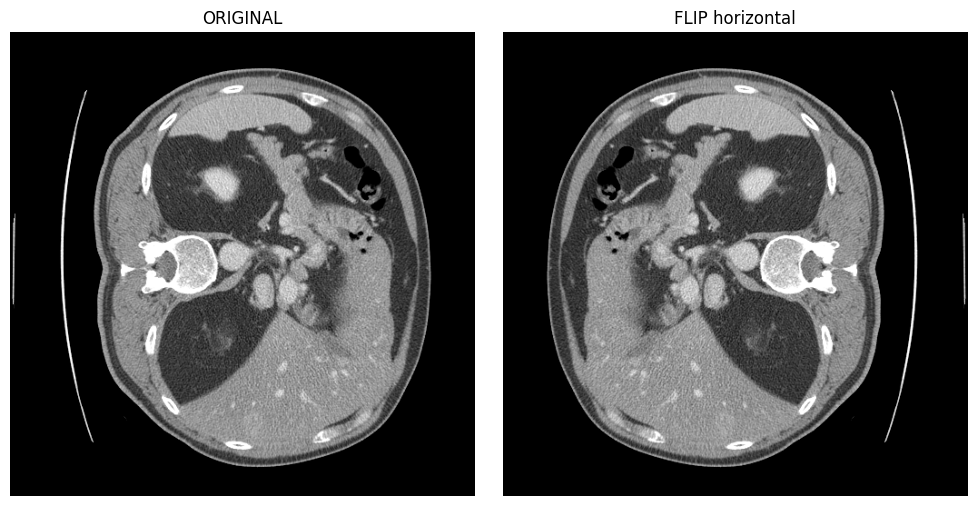

In [12]:
# =========================
# VISUALIZAR ORIGINAL vs AUGMENTADO
# =========================
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def show_pair(ct_path, title="", z=16):
    ct = nib.load(str(ct_path)).get_fdata()
    plt.imshow(ct[:, :, z], cmap="gray")
    plt.title(title)
    plt.axis("off")

# ---- elegí un ejemplo ----
orig_ct = ALL_DIR / "hepaticvessel_445_2_ventaneo_orig.nii.gz"
flip_ct = ALL_DIR / "hepaticvessel_445_2_ventaneo_flip.nii.gz"

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
show_pair(orig_ct, "ORIGINAL", z=16)

plt.subplot(1,2,2)
show_pair(flip_ct, "FLIP horizontal", z=16)

plt.tight_layout()
plt.show()


In [14]:
import nibabel as nib

p = orig_ct  # o poné Path a un CT cualquiera
img = nib.load(str(p))
print("shape:", img.shape)
print("axcodes:", nib.aff2axcodes(img.affine))
print("affine:\n", img.affine)


shape: (512, 512, 32)
axcodes: ('R', 'A', 'S')
affine:
 [[   0.80078101    0.            0.         -409.19909668]
 [   0.            0.80078101    0.         -409.19909668]
 [   0.            0.            1.5           0.        ]
 [   0.            0.            0.            1.        ]]


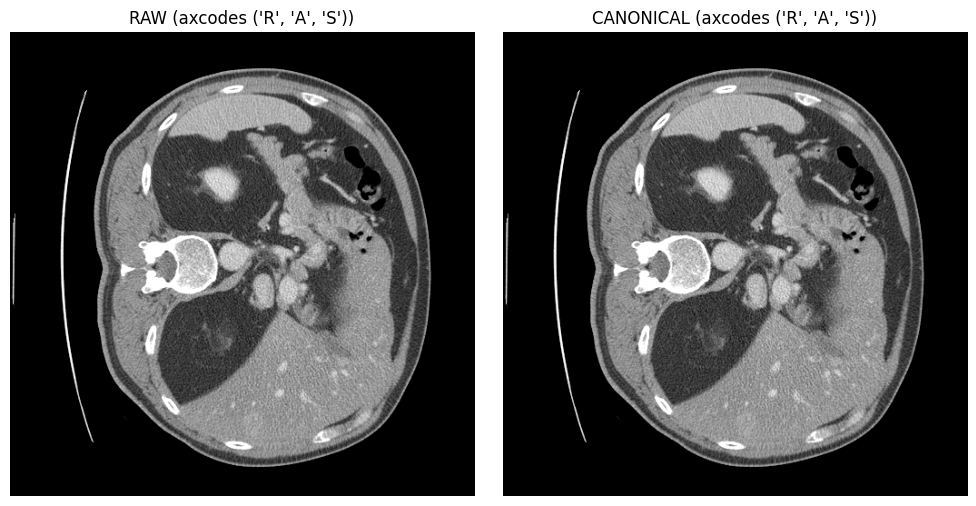

In [15]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def load_data(path):
    img = nib.load(str(path))
    data = img.get_fdata().astype(np.float32)
    return img, data

def to_canonical(img):
    can = nib.as_closest_canonical(img)  # reorienta a RAS+
    data = can.get_fdata().astype(np.float32)
    return can, data

img, ct = load_data(orig_ct)
can_img, ct_can = to_canonical(img)

z = 16
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(ct[:,:,z], cmap="gray"); plt.title(f"RAW (axcodes {nib.aff2axcodes(img.affine)})"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(ct_can[:,:,z], cmap="gray"); plt.title(f"CANONICAL (axcodes {nib.aff2axcodes(can_img.affine)})"); plt.axis("off")
plt.tight_layout(); plt.show()


ORIG: /users/lvelez/PI_Velez/data/Couinaud/imagesTr/hepaticvessel_001.nii.gz
WIN : /users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices/hepaticvessel_001_ventaneo_1.nii

--- ORIG ---
shape: (512, 512, 49) axcodes: ('R', 'A', 'S')
affine:
 [[   0.91796899    0.            0.         -469.08215332]
 [   0.            0.91796899    0.         -469.08215332]
 [   0.            0.            5.            0.        ]
 [   0.            0.            0.            1.        ]]

--- WIN ---
shape: (512, 512, 32) axcodes: ('R', 'A', 'S')
affine:
 [[   0.91796899    0.            0.         -469.08215332]
 [   0.            0.91796899    0.         -469.08215332]
 [   0.            0.            5.            0.        ]
 [   0.            0.            0.            1.        ]]


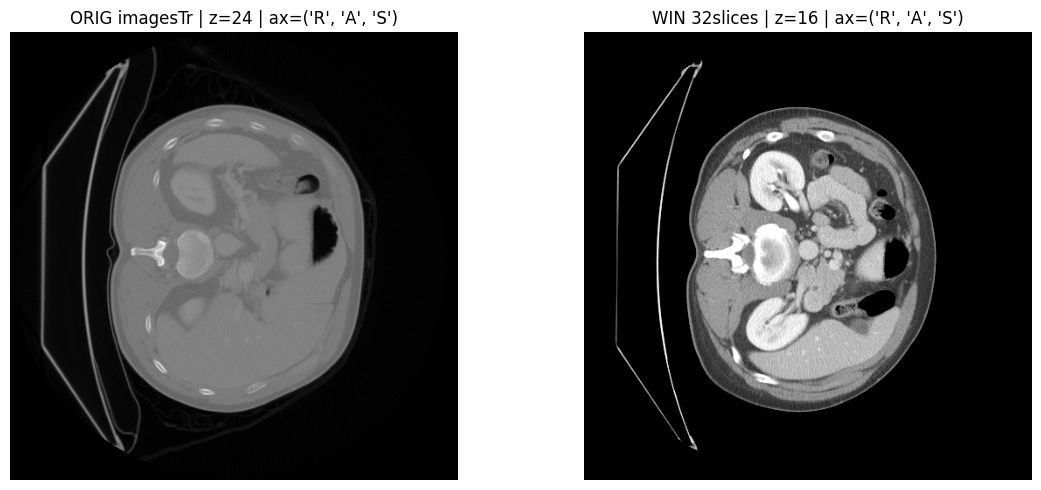

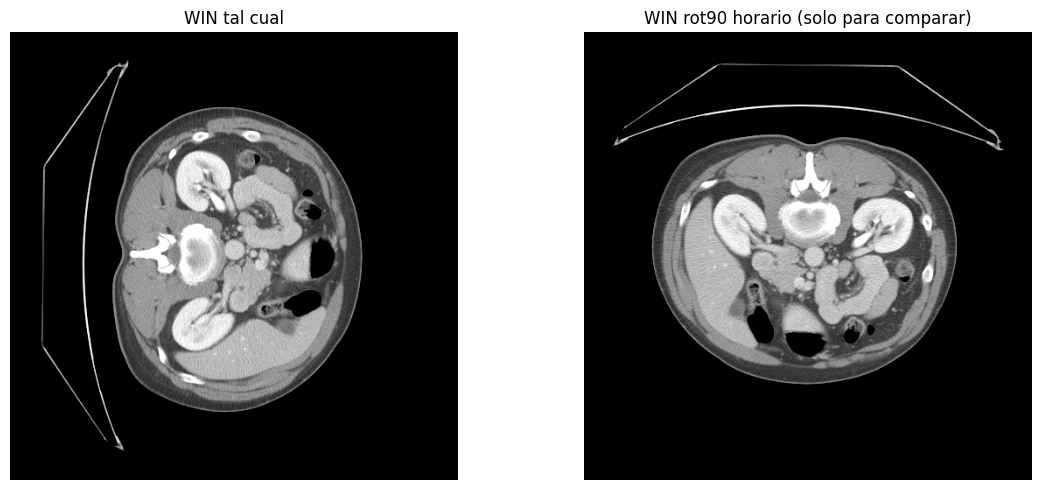

In [16]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==========
# CONFIG
# ==========
PID = "hepaticvessel_001"  # <-- cambia esto por el paciente que quieras

IMAGES_TR = Path("/users/lvelez/PI_Velez/data/Couinaud/imagesTr")
WIN32_DIR = Path("/users/lvelez/PI_Velez/data/Couinaud/CouinaudTr/32slices")

# --- buscar CT original en imagesTr (acepta .nii o .nii.gz)
orig_candidates = sorted(list(IMAGES_TR.glob(f"{PID}.nii")) + list(IMAGES_TR.glob(f"{PID}.nii.gz")))
assert orig_candidates, f"No encontré CT original para {PID} en {IMAGES_TR}"
orig_path = orig_candidates[0]

# --- buscar CT ventaneada en 32slices (puede ser con o sin _idx)
# ej: hepaticvessel_001_ventaneo.nii.gz o hepaticvessel_001_ventaneo_1.nii.gz
win_candidates = sorted(list(WIN32_DIR.glob(f"{PID}_ventaneo*.nii")) + list(WIN32_DIR.glob(f"{PID}_ventaneo*.nii.gz")))
assert win_candidates, f"No encontré CT ventaneada para {PID} en {WIN32_DIR}"
win_path = win_candidates[0]

print("ORIG:", orig_path)
print("WIN :", win_path)

def load_info(p: Path):
    img = nib.load(str(p))
    data = img.get_fdata().astype(np.float32)
    ax = nib.aff2axcodes(img.affine)
    return img, data, ax

img_o, o, ax_o = load_info(orig_path)
img_w, w, ax_w = load_info(win_path)

print("\n--- ORIG ---")
print("shape:", o.shape, "axcodes:", ax_o)
print("affine:\n", img_o.affine)

print("\n--- WIN ---")
print("shape:", w.shape, "axcodes:", ax_w)
print("affine:\n", img_w.affine)

# elegir slice a mostrar (centro del volumen disponible)
z_o = o.shape[2] // 2
z_w = w.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(o[:, :, z_o], cmap="gray")
plt.title(f"ORIG imagesTr | z={z_o} | ax={ax_o}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(w[:, :, z_w], cmap="gray")
plt.title(f"WIN 32slices | z={z_w} | ax={ax_w}")
plt.axis("off")

plt.tight_layout()
plt.show()

# Extra: si querés verificar “si es rotación del array”
# mostramos también una versión rot90 para comparar visualmente rápido:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(w[:, :, z_w], cmap="gray")
plt.title("WIN tal cual")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.rot90(w[:, :, z_w], k=-1), cmap="gray")
plt.title("WIN rot90 horario (solo para comparar)")
plt.axis("off")

plt.tight_layout()
plt.show()


axcodes: ('R', 'A', 'S')
shape: (512, 512, 32)


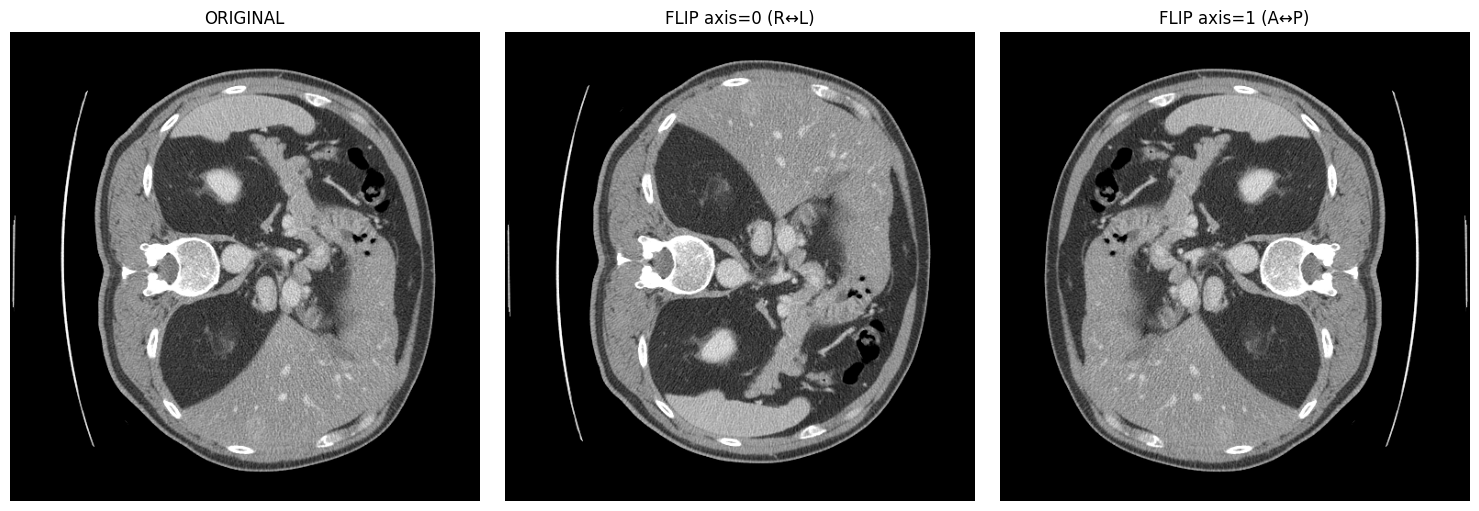

In [17]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==========
# ELEGÍ UN CT
# ==========
# usá uno ventaneado que ya tengas
ct_path = ALL_DIR / "hepaticvessel_445_2_ventaneo_orig.nii.gz"

img = nib.load(str(ct_path))
ct = img.get_fdata().astype(np.float32)

axcodes = nib.aff2axcodes(img.affine)
print("axcodes:", axcodes)
print("shape:", ct.shape)

z = ct.shape[2] // 2

# ==========
# FLIPS
# ==========
flip_axis0 = np.flip(ct, axis=0)  # R <-> L
flip_axis1 = np.flip(ct, axis=1)  # A <-> P

# ==========
# VISUALIZACIÓN
# ==========
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(ct[:, :, z], cmap="gray")
plt.title("ORIGINAL")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(flip_axis0[:, :, z], cmap="gray")
plt.title("FLIP axis=0 (R↔L)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(flip_axis1[:, :, z], cmap="gray")
plt.title("FLIP axis=1 (A↔P)")
plt.axis("off")

plt.tight_layout()
plt.show()
